# 02 — Data Exploration

This notebook explores the **Solubility_AqSolDB** benchmark obtained from the Therapeutics Data Commons (TDC).

The objective of this stage is to understand the structure and main characteristics of the dataset before generating molecular representations or training machine learning models.

No persistent preprocessing transformations are applied to the benchmark data. Temporary derived columns may be created exclusively for exploratory analysis.

## Objectives

- Inspect the structure and dimensions of the train/validation and test sets.
- Review column names and data types.
- Check for missing values and duplicated molecular structures.
- Examine the distribution and range of the target variable (`Y`).
- Identify potential data quality issues that may require further treatment.
- Establish the basis for the subsequent molecular feature engineering stage.


In [ ]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
import pandas as pd
import matplotlib.pyplot as plt

from tdc.benchmark_group import admet_group

RDLogger.DisableLog("rdApp.warning")

group = admet_group(path="../data/raw/")
benchmark = group.get("Solubility_AqSolDB")

Found local copy...


In [56]:
train_val = benchmark["train_val"].copy()
test = benchmark["test"].copy()

print("Train + validation")
print("------------------")
print("Shape:", train_val.shape)
print("Columns:", train_val.columns.tolist())

print()

print("Test")
print("----")
print("Shape:", test.shape)
print("Columns:", test.columns.tolist())

Train + validation
------------------
Shape: (7985, 3)
Columns: ['Drug_ID', 'Drug', 'Y']

Test
----
Shape: (1997, 3)
Columns: ['Drug_ID', 'Drug', 'Y']


In [57]:
print("Train + validation dtypes:")
print(train_val.dtypes)

print("Test dtypes:")
print(test.dtypes)

Train + validation dtypes:
Drug_ID        str
Drug           str
Y          float64
dtype: object
Test dtypes:
Drug_ID        str
Drug           str
Y          float64
dtype: object


In [58]:
train_val.head()

,Drug_ID,Drug,Y
0,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
1,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
2,4-(dimethylamino)benzaldehyde,CN(C)c1ccc(C=O)cc1,-2.282769
3,2-methyl-1-phenylpropan-2-yl acetate,CC(=O)OC(C)(C)Cc1ccccc1,-2.394650
4,5-methoxy-1-[4-(trifluoromethyl)phenyl]pentan-...,COCCCCC(=O)c1ccc(C(F)(F)F)cc1,-3.544060


In [59]:
print("Train + validation nulls:\n", train_val.isnull().sum(), "\n")

print("Test nulls:\n", test.isnull().sum())

Train + validation nulls:
 Drug_ID    0
Drug       0
Y          0
dtype: int64 

Test nulls:
 Drug_ID    0
Drug       0
Y          0
dtype: int64


No missing values are present in the train + validation set. Additional checks are still required to assess molecular duplicates, target distribution, and structural validity.

### Target variable

The prediction target is aqueous solubility expressed as log10(mol/L).

This is a continuous target, so the task is formulated as a regression problem.

In [60]:
print("Aqueous solubility (Y) distribution:\n")
print(train_val["Y"].describe())

print("\nAqueous solubility (Y) quantiles (expanded):")
train_val["Y"].quantile([
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99
])

Aqueous solubility (Y) distribution:

count    7985.000000
mean       -2.761690
std         2.368903
min       -12.060500
25%        -4.171800
50%        -2.467000
75%        -1.065100
max         1.967513
Name: Y, dtype: float64

Aqueous solubility (Y) quantiles (expanded):


0.01   -8.756998
0.05   -7.330344
0.25   -4.171800
0.50   -2.467000
0.75   -1.065100
0.95    0.711671
0.99    1.130085
Name: Y, dtype: float64

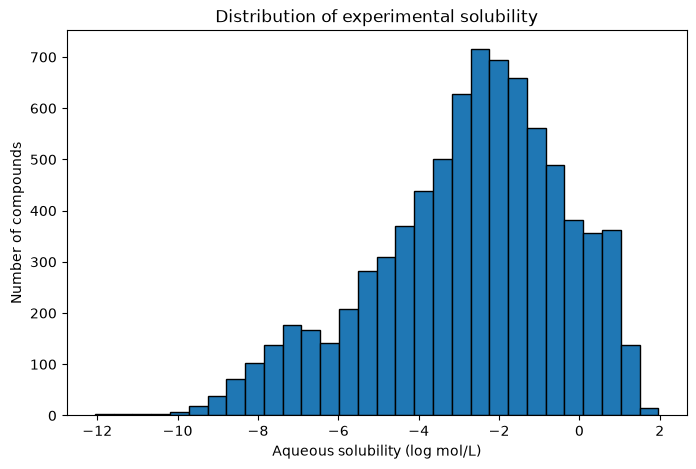

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_val["Y"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Aqueous solubility (log mol/L)")
plt.ylabel("Number of compounds")
plt.title("Distribution of experimental solubility")

plt.show()

In [62]:
train_val["mol"] = train_val["Drug"].apply(Chem.MolFromSmiles)

n_invalid = train_val["mol"].isna().sum()

print(f"Invalid SMILES: {n_invalid}")

Invalid SMILES: 0


In [63]:
train_val["canonical_smiles"] = train_val["mol"].apply(
    lambda mol: Chem.MolToSmiles(mol, canonical=True)
    if mol is not None
    else None
)

In [64]:
print("Original rows:", len(train_val))
print("Valid RDKit molecules:", train_val["mol"].notna().sum())
print("Invalid RDKit molecules:", train_val["mol"].isna().sum())

print(
    "Exact SMILES duplicates:",
    train_val["Drug"].duplicated().sum()
)

print(
    "Canonical structure duplicates:",
    train_val["canonical_smiles"].duplicated().sum()
)

Original rows: 7985
Valid RDKit molecules: 7985
Invalid RDKit molecules: 0
Exact SMILES duplicates: 0
Canonical structure duplicates: 0


No exact or canonical molecular duplicates were found in the training/validation set. Therefore, no duplicate-resolution strategy is required at this stage.

In [65]:
def compute_basic_properties(mol):
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
    })


In [66]:
basic_properties = train_val["mol"].apply(compute_basic_properties)

eda_df = pd.concat(
    [train_val[["Drug", "canonical_smiles", "Y"]], basic_properties],
    axis=1
)

In [67]:
eda_df.describe()

,Y,MolWt,LogP,HBD,HBA,TPSA,RotatableBonds,RingCount,HeavyAtomCount
count,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000
mean,-2.761690,255.876356,1.873667,1.068503,3.309080,60.350274,4.210394,1.304321,16.530244
std,2.368903,171.262221,3.558792,1.450223,3.233622,60.169018,5.957563,1.567315,11.401067
min,-12.060500,9.012000,-40.873200,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,-4.171800,154.253000,0.541000,0.000000,1.000000,25.780000,1.000000,0.000000,10.000000
50%,-2.467000,218.256000,1.845500,1.000000,3.000000,48.910000,3.000000,1.000000,14.000000
75%,-1.065100,307.620000,3.306540,2.000000,4.000000,78.430000,5.000000,2.000000,20.000000
max,1.967513,2967.981000,68.541140,24.000000,40.000000,966.000000,141.000000,30.000000,185.000000


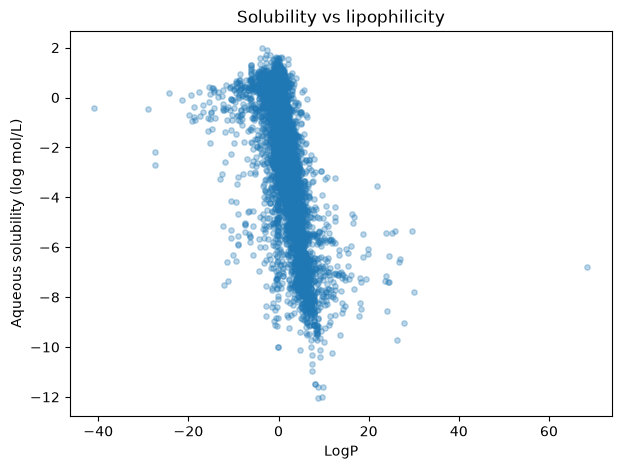

In [68]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    eda_df["LogP"],
    eda_df["Y"],
    alpha=0.3,
    s=15
)

ax.set_xlabel("LogP")
ax.set_ylabel("Aqueous solubility (log mol/L)")
ax.set_title("Solubility vs lipophilicity")

plt.show()

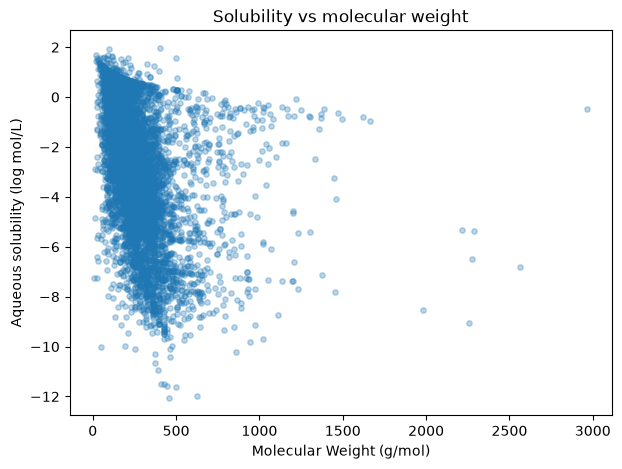

In [69]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    eda_df["MolWt"],
    eda_df["Y"],
    alpha=0.3,
    s=15
)

ax.set_xlabel("Molecular Weight (g/mol)")
ax.set_ylabel("Aqueous solubility (log mol/L)")
ax.set_title("Solubility vs molecular weight")

plt.show()

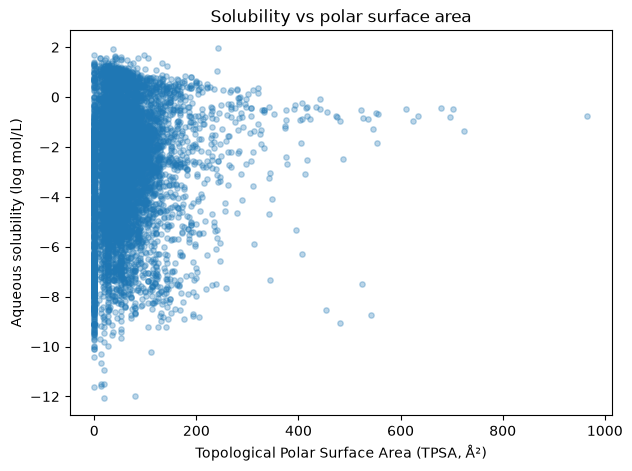

In [70]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    eda_df["TPSA"],
    eda_df["Y"],
    alpha=0.3,
    s=15
)

ax.set_xlabel("Topological Polar Surface Area (TPSA, Å²)")
ax.set_ylabel("Aqueous solubility (log mol/L)")
ax.set_title("Solubility vs polar surface area")

plt.show()

In [71]:
eda_df[
    ["Y", "MolWt", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds"]
].corr(method="spearman")

,Y,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds
Y,1.000000,-0.546841,-0.731317,0.133043,0.238198,0.023926,-0.175316
MolWt,-0.546841,1.000000,0.427844,0.424069,0.111471,0.537701,0.506418
LogP,-0.731317,0.427844,1.000000,-0.385642,-0.305143,-0.210201,0.246534
TPSA,0.133043,0.424069,-0.385642,1.000000,0.584102,0.848774,0.347608
HBD,0.238198,0.111471,-0.305143,0.584102,1.000000,0.338473,0.157228
HBA,0.023926,0.537701,-0.210201,0.848774,0.338473,1.000000,0.461978
RotatableBonds,-0.175316,0.506418,0.246534,0.347608,0.157228,0.461978,1.000000


The physicochemical descriptors show varying degrees of monotonic association with aqueous solubility. None of the individual properties appears sufficient to explain the target alone, supporting the use of richer multivariate molecular representations in the feature engineering stage.

## Conclusions

- The training/validation partition contains 7,985 molecules.
- No missing values were identified.
- All SMILES could be parsed successfully by RDKit.
- No exact or canonical molecular duplicates were found.
- Aqueous solubility spans a broad range of values.
- Basic physicochemical properties show associations with solubility, but no single descriptor fully explains the target variability.
- No observations are removed during exploratory analysis.
- Molecular representations will be generated in the feature engineering stage, while the official TDC benchmark split will be used for model development and evaluation.